## Preprocessing Notebook

#### Data Source
First, we take the GLDv2 dataset and merge the train and index csv.

For each landmark, we find the relevant wikimedia url (available on GLDv2 repo as well).

We remove records that doesn't have valid wikimedia url.

In [1]:
from collections import Counter

import hdbscan
import numpy as np
import polars as pl
import torch
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### Metadata Mining
We collect additional metadata from the wikimedia url such as: latitude, longitude, P31 instance of tags, and landmark name.

We then remove the records that doesn't have valid latitude, longitude, and P31 tags.

To collect additional metadata from wikidata, run this script:
```bash
python -m src.data.scrap_wikimedia --data-path /mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/all_wikimedia_url_need_scrap.csv --output-path /mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/all_wikimedia_url_need_scrap_out.csv --scrape geohack wikimedia --wikidata-worker 10 --max-pages 10 --keep-input-url
```

In [265]:
wiki_df = (
    pl.read_csv(
        "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/all_wikimedia_url.csv"
    )
    .filter(pl.col("latitude").is_not_null() & pl.col("longitude").is_not_null())
    .with_columns(pl.col("latitude", "longitude").cast(pl.Float64, strict=False))
    .drop("error")
)

additional_wiki = (
    pl.read_csv(
        "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/all_wikimedia_url_need_scrap_out.csv"
    )
    .filter(pl.col("latitude").is_not_null() & pl.col("longitude").is_not_null())
    .drop("error")
)

In [ ]:
train = (
    pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/raw-from-github/train.csv")
    .rename({"resolved_url": "wikimedia_url"})
    .select(["id", "landmark_id", "wikimedia_url"])
    .with_columns(pl.lit("train").alias("src"))
    .join(wiki_df, on="wikimedia_url", how="left")
)

train_leftover = (
    train.filter(pl.col("latitude").is_null())
    .select(["id", "landmark_id", "wikimedia_url", "src"])
    .join(additional_wiki, left_on="wikimedia_url", right_on="input_wikimedia_url")
    .with_columns(pl.col("wikimedia_url_right").alias("wikimedia_url"))
    .drop("wikimedia_url_right")
)

train = pl.concat(
    [
        train.filter(
            pl.col("latitude").is_not_null() & pl.col("longitude").is_not_null()
        ),
        train_leftover,
    ]
).unique("id")

index = (
    pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/raw-from-github/index.csv")
    .with_columns(pl.lit("index").alias("src"))
    .join(
        additional_wiki,
        left_on="wikimedia_url",
        right_on="input_wikimedia_url",
        how="left",
    )
    .with_columns(pl.col("wikimedia_url_right").alias("wikimedia_url"))
    .drop("wikimedia_url_right")
    .filter(pl.col("latitude").is_not_null() & pl.col("longitude").is_not_null())
)

raw_train_index = pl.concat([train, index])

In [ ]:
raw_train_index.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/raw_train_index.csv"
)

##### Reverse Geocode

To obtain country and city name, we need to do reverse geocoding. Run this script:
```bash
python -m src.data.reverse_geocode -i /mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/raw_train_index.csv -o /mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/raw_train_index_geo.csv
```

### Wikidata Preprocessing

#### P31 Tags Processing
The nature of P31 tags are very diverse and sometimes very specific (fine-grained) that we believe quite rare to be mentioned in user query.

Therefore, we attempt to flatten and group them by generating coarser taxonomy.

Our approach quite straightforward:
- First, we leverage BERTopic to identify clusters among the tags.
- Instead of taking the cTF-IDF keywords from BERTopic to represent the clusters, we pair the original tags with topic labels.
- We then feed the representative tags to LLM to generate 3 keywords candidate to represent the cluster.
- Finally, we ask human validator to select one keyword that best representing the topic/cluster.

##### Postprocessing
HDBSCAN will flag the outlier tags and assign class of `-1` to them.

To mitigate this, we measure the distance between each cluster centroid embedding and each individual tag that flagged as outlier.

Specifically, we take the average of tag embeddings from each cluster. We later call this as cluster centroid embedding.

Then, we compare each one of tag embedding with class of `-1` with all cluster centroid embedding.

We then assign the cluster class to its nearest centroid embedding.

In [2]:
df = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/raw_train_index.csv"
)
df_tag_clean = df.with_columns(
    pl.col("instance_tag").str.split(",").alias("instance_tag")
).with_columns(
    pl.col("instance_tag")
    .list.eval(
        pl.element().filter(
            ~pl.element().is_in(["Wikimedia category"])
            & ~pl.element().str.contains(r"^Q\d+$")
        )
    )
    .alias("instance_tag_clean")
)

In [3]:
flatten_tags = []
for tag in df_tag_clean.unique("wikimedia_url")["instance_tag_clean"].to_list():
    if not tag:
        continue
    for t in tag:
        flatten_tags.append(t)

ctags = Counter(flatten_tags)
tags = list(ctags.keys())

#### UMAP + HDBSCAN + Agglomerative Clustering (TBC | WIP)

In [179]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2").to(DEVICE)
# model = SentenceTransformer(
#     "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# ).to(DEVICE)
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
).to(DEVICE)
reductor = UMAP(metric="cosine", n_components=15, random_state=42)

MIN_CLUSTER_SIZES = [5, 10, 15, 20, 25, 50, 100]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
tag_embeddings = model.encode(tags)
r_tag_embeddings = reductor.fit_transform(tag_embeddings).astype(np.float64)

In [ ]:
def tune_hdbscan(reduced_embeddings, min_cluster_sizes):
    results = []
    for size in min_cluster_sizes:
        clusterer = HDBSCAN(min_cluster_size=size).fit(reduced_embeddings)
        labels = clusterer.labels_
        score = hdbscan.validity.validity_index(reduced_embeddings, labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1) * 100
        results.append(
            {
                "min_cluster_size": size,
                "dbcv": score,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "clf": clusterer,
            }
        )
        print(
            f"Min Cluster Size: {size} -> DBCV: {score:.3f}, "
            f"Clusters: {n_clusters}, Noise: {noise_ratio:.2f}%"
        )

    return results


def inspect_clusters(tags, clusterer, top_n=10):
    df_tags_cluster = pl.DataFrame(
        {
            "tags": tags,
            "labels": clusterer.labels_,
            "probability": clusterer.probabilities_,
        }
    )

    n_total = len(df_tags_cluster)
    n_noise = (df_tags_cluster["labels"] == -1).sum()
    print(f"Noise: {n_noise} tags ({n_noise / n_total * 100:.2f}%)\n")

    summary = (
        df_tags_cluster.filter(pl.col("labels") != -1)
        .group_by("labels")
        .agg(pl.len().alias("size"))
        .with_columns(
            pl.col("labels")
            .map_elements(
                lambda l: float(clusterer.cluster_persistence_[l]),
                return_dtype=pl.Float64,
            )
            .alias("persistence")
        )
        .sort("persistence", descending=True)
    )

    top_tags = (
        df_tags_cluster.filter(pl.col("labels") != -1)
        .sort("probability", descending=True)
        .group_by("labels", maintain_order=True)
        .agg(pl.col("tags").head(top_n))
    )

    cluster_summary = summary.join(top_tags, on="labels")

    for row in cluster_summary.sort("labels").to_dicts():
        print(
            f"Cluster {row['labels']} | size={row['size']} | persistence={row['persistence']:.3f}"
        )
        print(row["tags"])
        print("-" * 10)

    # return df_tags_cluster, cluster_summary


def get_cluster_centroid(cluster_id, tag_embeddings, cluster_labels):
    member_idx = np.where(cluster_labels == cluster_id)[0]
    cluster_embeddings = tag_embeddings[member_idx]
    return cluster_embeddings.mean(axis=0)

In [102]:
tune_results = tune_hdbscan(r_tag_embeddings, MIN_CLUSTER_SIZES)

Min Cluster Size: 5 -> DBCV: 0.359, Clusters: 177, Noise: 19.50%
Min Cluster Size: 10 -> DBCV: 0.457, Clusters: 87, Noise: 22.63%
Min Cluster Size: 15 -> DBCV: 0.418, Clusters: 65, Noise: 23.77%
Min Cluster Size: 20 -> DBCV: 0.382, Clusters: 48, Noise: 26.45%
Min Cluster Size: 25 -> DBCV: 0.373, Clusters: 36, Noise: 29.60%
Min Cluster Size: 50 -> DBCV: 0.346, Clusters: 17, Noise: 43.19%
Min Cluster Size: 100 -> DBCV: 0.163, Clusters: 4, Noise: 36.26%


In [106]:
inspect_clusters(tags, tune_results[1]["clf"], top_n=20)

Noise: 1107 tags (22.63%)

Cluster 0 | size=15 | persistence=0.140
['courthouse', 'county courthouse', 'former courthouse', 'cascina a corte', 'high court', 'appellate court', 'court', 'Gerichtslinde', 'court cairn', 'international court', 'supreme court', 'legal person', 'casemate', 'law school', 'law library']
----------
Cluster 1 | size=18 | persistence=0.069
['hospital', 'psychiatric hospital', 'former hospital', 'medical museum', 'clinic', 'hospital museum', 'veterinary hospital', 'medical organization', 'history of medicine', 'teaching hospital', 'medical library', 'university hospital', 'ambulance station', 'Hospital of Santa Maria Nuova', 'pharmacy', 'pillbox', 'hospital church', 'hospital chapel']
----------
Cluster 2 | size=13 | persistence=0.078
['town of China', 'prefecture-level city of China', 'subdistrict in China', "administrative territorial entity of the People's Republic of China", "village of the People's Republic of China", 'province of China', 'Chinese city wall',

In [152]:
from sklearn.cluster import AgglomerativeClustering

aggcluster = AgglomerativeClustering(
    metric="cosine", linkage="average", distance_threshold=0.5, n_clusters=None
)
aggcluster.fit(centroid_embeddings)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'cosine'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0.5
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


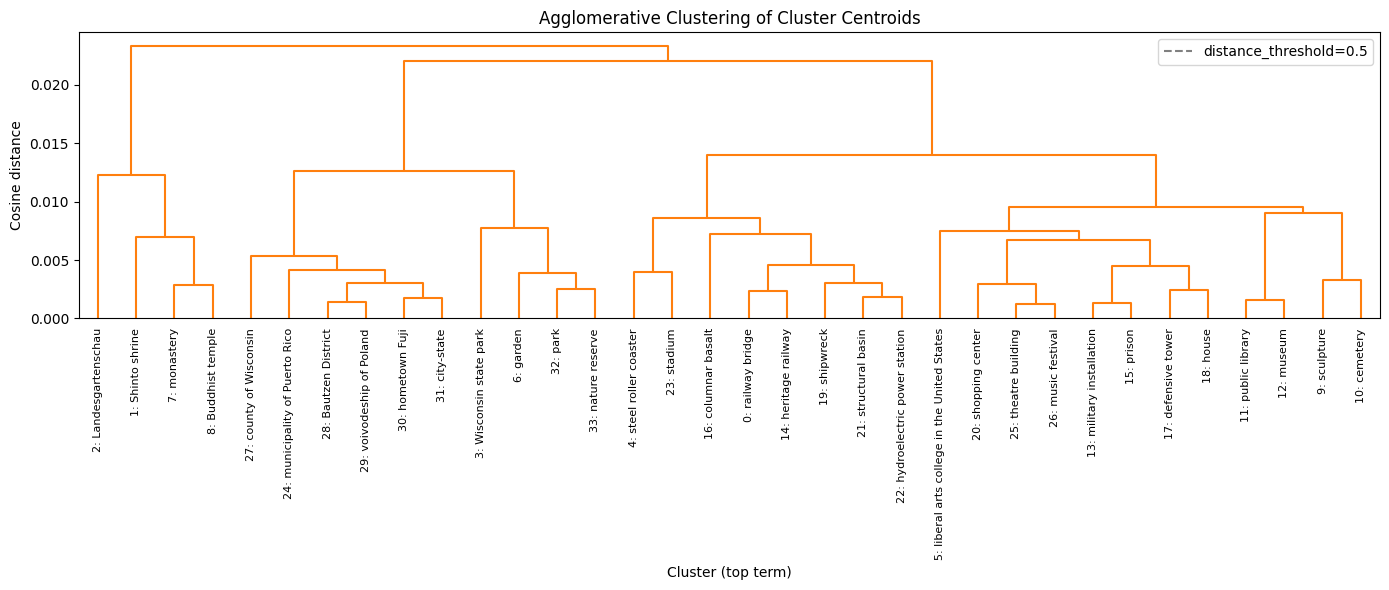

In [153]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


cluster_ids = sorted(cid for cid in np.unique(clusterer.labels_) if cid >= 0)

top_term_by_cluster = {
    row["labels"]: row["tags"][0] for row in cluster_summary.to_dicts()
}
leaf_labels = [f"{cid}: {top_term_by_cluster[cid]}" for cid in cluster_ids]

plt.figure(figsize=(14, 6))
plot_dendrogram(aggcluster, labels=leaf_labels, color_threshold=0.5)
plt.axhline(y=0.5, color="gray", linestyle="--", label="distance_threshold=0.5")
plt.xlabel("Cluster (top term)")
plt.ylabel("Cosine distance")
plt.title("Agglomerative Clustering of Cluster Centroids")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
tune_hdbscan(centroid_embeddings, MIN_CLUSTER_SIZES)

Min Cluster Size: 5 -> DBCV: 0.190, Clusters: 2, Noise: 37.65%
Min Cluster Size: 10 -> DBCV: 0.175, Clusters: 2, Noise: 48.24%
Min Cluster Size: 15 -> DBCV: 0.000, Clusters: 0, Noise: 100.00%
Min Cluster Size: 20 -> DBCV: 0.000, Clusters: 0, Noise: 100.00%
Min Cluster Size: 25 -> DBCV: 0.000, Clusters: 0, Noise: 100.00%


min_cluster_size,dbcv,n_clusters,noise_ratio
i64,f64,i64,f64
5,0.189716,2,37.647059
10,0.175136,2,48.235294
15,0.0,0,100.0
20,0.0,0,100.0
25,0.0,0,100.0


In [78]:
import hdbscan
import numpy as np

r_tag_embeddings_f64 = r_tag_embeddings.astype("float64")

for size in [5, 10] + list(range(11, 20)) + [20, 25, 50, 100]:
    clusterer = HDBSCAN(min_cluster_size=size).fit(r_tag_embeddings_f64)
    labels = clusterer.labels_
    score = hdbscan.validity.validity_index(r_tag_embeddings_f64, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1) * 100
    print(
        f"Min Cluster Size: {size} -> DBCV: {score:.3f}, "
        f"Clusters: {n_clusters}, Noise: {noise_ratio:.2f}%"
    )

Min Cluster Size: 5 -> DBCV: 0.364, Clusters: 184, Noise: 30.58%
Min Cluster Size: 10 -> DBCV: 0.342, Clusters: 85, Noise: 30.52%
Min Cluster Size: 11 -> DBCV: 0.355, Clusters: 78, Noise: 31.70%
Min Cluster Size: 12 -> DBCV: 0.357, Clusters: 72, Noise: 31.32%
Min Cluster Size: 13 -> DBCV: 0.348, Clusters: 68, Noise: 33.77%
Min Cluster Size: 14 -> DBCV: 0.362, Clusters: 63, Noise: 32.87%
Min Cluster Size: 15 -> DBCV: 0.346, Clusters: 57, Noise: 35.22%
Min Cluster Size: 16 -> DBCV: 0.341, Clusters: 51, Noise: 36.12%
Min Cluster Size: 17 -> DBCV: 0.358, Clusters: 50, Noise: 36.71%
Min Cluster Size: 18 -> DBCV: 0.351, Clusters: 48, Noise: 37.02%
Min Cluster Size: 19 -> DBCV: 0.345, Clusters: 45, Noise: 37.63%
Min Cluster Size: 20 -> DBCV: 0.331, Clusters: 45, Noise: 38.57%
Min Cluster Size: 25 -> DBCV: 0.334, Clusters: 34, Noise: 38.39%
Min Cluster Size: 50 -> DBCV: 0.315, Clusters: 15, Noise: 41.11%
Min Cluster Size: 100 -> DBCV: 0.271, Clusters: 6, Noise: 59.75%


In [86]:
clusterer = HDBSCAN(min_cluster_size=25, prediction_data=True).fit(
    r_tag_embeddings.astype("float64")
)
cluster_labels = clusterer.labels_

# to predict cluster membership for NEW/unseen points later:
# new_labels, strengths = hdbscan.approximate_predict(clusterer, new_points.astype("float64"))

In [ ]:
df_tags_cluster, cluster_summary = inspect_clusters(tags, clusterer)

#### BERTopic

In [352]:
from bertopic import BERTopic

tm = BERTopic(
    # language="multilingual",
    min_topic_size=25,
    # hdbscan_model=HDBSCAN(min_cluster_size=25),
    umap_model=UMAP(metric="cosine", n_components=15, random_state=42),
    # hdbscan_model=tune_results[1]["clf"],
    # umap_model=reductor,
    embedding_model=SentenceTransformer(
        "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    ).to(DEVICE),
    n_gram_range=(1, 3),
)
topics, probs = tm.fit_transform(tags)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/home/affahrizain/project/s4-landmark-ir/.venv/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [353]:
tags_df = pl.DataFrame({"tags": tags, "cluster": topics, "probability": probs})

summary = (
    tags_df.filter(pl.col("cluster") != -1)
    .group_by("cluster")
    .agg(pl.len().alias("size"))
)

top_tags = (
    tags_df.filter(pl.col("cluster") != -1)
    .sort("probability", descending=True)
    .group_by("cluster", maintain_order=True)
    .agg(pl.col("tags").head(20))
)

cluster_summary = summary.join(top_tags, on="cluster")

for row in cluster_summary.sort("cluster").to_dicts():
    print(f"Cluster {row['cluster']} | size={row['size']}")
    print(row["tags"])
    print("-" * 10)

Cluster 0 | size=875
['menhir', 'mine', 'masia', 'hokora', 'province of Japan', 'Shikinai Ronsha', 'fort', 'spa', 'one-thousander', 'cape', 'castrum', 'Zapis', 'polonyna', 'hometown Fuji', 'sconce', 'madrasa', 'Vekoma Madhouse', 'skete', 'tor', 'Simultaneum']
----------
Cluster 1 | size=265
['church building', 'minor basilica', 'parish church', 'aisleless church', 'Catholic cathedral', 'village church', 'Protestant church building', 'Catholic parish church', 'former church building', 'Catholic pilgrimage church', 'secularized church', 'baptistery', 'Catholic seminary', 'diocese of the Catholic Church', 'Lutheran church', 'wooden church', 'timber-framed church', 'Roman Catholic monastery', 'churches of Teutonic Order', 'religious building']
----------
Cluster 2 | size=215
['regional park', 'park', 'Naturschutzgebiet', 'nature reserve in the Czech Republic', 'recreation area', 'urban park', 'nature reserve', 'national park', 'national park of Russia', 'Tokyo metropolitan park', 'nature p

In [359]:
import requests
from tqdm.auto import tqdm

OLLAMA_HOST = "http://localhost:11434"
OLLAMA_MODEL = "qwen3.5:latest"

KEYWORD_SYSTEM_PROMPT = (
    'You are labeling clusters of Wikidata landmark/place "instance of" tags '
    "for a landmark-type taxonomy. You will be given a list of short tags that "
    "were grouped together because their embeddings are similar.\n\n"
    "Your job: propose up to 3 candidate NOUNS that could each name the "
    "landmark TYPE shared by most of the tags — the kind of place or structure "
    "they describe, not their location, era, style, or administrative status. "
    "A human will pick the best one from your candidates, so give distinct, "
    "genuinely different options rather than near-duplicates of the same word.\n\n"
    "Rules:\n"
    "1. Each candidate should be ONE word if possible; use a second word only "
    'if one word would be ambiguous or wrong (e.g. "state park").\n'
    "2. Singular form, lowercase, no punctuation.\n"
    "3. Order candidates from most to least representative/confident.\n"
    "4. Prefer common, general English terms — not rare synonyms, not overly "
    "specific subtypes, not proper nouns.\n"
    "5. If the tags mainly describe an administrative or geographic entity "
    "rather than a landmark type, or are too unrelated to share any single "
    "type, respond with exactly: OTHER\n"
    "6. Output ONLY the candidates, one per line, nothing else — no numbering, "
    "no explanation, no punctuation."
)

FEW_SHOT_EXAMPLES = [
    (
        "defensive tower, observation tower, fortified tower, tower, communication "
        "tower, Irish round tower, lattice tower, coastal tower, fire lookout tower, "
        "Leaning Tower of Pisa",
        ["tower", "watchtower", "lookout"],
    ),
    (
        "Wisconsin state park, California state park, Washington state park, "
        "state park, Kentucky state park, Arkansas state park",
        ["state park", "park", "protected area"],
    ),
    (
        "county of Wisconsin, county of Tennessee, county seat, Humboldt County, "
        "registration county, county of Nevada, county of Oregon",
        # ["county", "administrative division", "district"],
        ["other"],
    ),
    (
        "Landesgartenschau, Rathaus, Naturschutzgebiet, Shikinaisha, Betsu-gū, "
        "Kōtai Jingū, Itsukushima, jingū, chokusaisha",
        ["shrine", "civic building", "garden"],
    ),
]

FEW_SHOT_MESSAGES = [{"role": "system", "content": KEYWORD_SYSTEM_PROMPT}]
for _tags, _keyword in FEW_SHOT_EXAMPLES:
    FEW_SHOT_MESSAGES.append({"role": "user", "content": f"Tags: {_tags}"})
    FEW_SHOT_MESSAGES.append({"role": "assistant", "content": ",".join(_keyword)})


def generate_cluster_keyword(
    tags: list[str], model: str = OLLAMA_MODEL, retries: int = 3
) -> str:
    tag_list = ", ".join(tags)
    payload = {
        "model": model,
        "messages": FEW_SHOT_MESSAGES
        + [{"role": "user", "content": f"Tags: {tag_list}"}],
        "think": False,
        "stream": False,
        "options": {"temperature": 0, "num_predict": 50},
    }
    for attempt in range(retries):
        try:
            resp = requests.post(f"{OLLAMA_HOST}/api/chat", json=payload, timeout=1800)
            resp.raise_for_status()
            keyword = resp.json()["message"]["content"].strip()
            if keyword:
                return keyword
        except Exception as e:
            if attempt == retries - 1:
                print(f"Failed to generate keyword for tags [{tag_list[:50]}...]: {e}")
                return "unknown"
    return "unknown"


cluster_keywords = {}
for row in tqdm(
    cluster_summary.sort("cluster").to_dicts(), desc="Generating cluster keywords"
):
    cluster_keywords[row["cluster"]] = generate_cluster_keyword(row["tags"])

Generating cluster keywords:   0%|          | 0/46 [00:00<?, ?it/s]

In [360]:
cluster_summary = cluster_summary.with_columns(
    pl.col("cluster")
    .map_elements(lambda l: cluster_keywords.get(l, "unknown"), return_dtype=pl.Utf8)
    .alias("representative_keyword")
)

cluster_summary.sort("cluster")

cluster,size,tags,representative_keyword
i64,u32,list[str],str
0,875,"[""menhir"", ""mine"", … ""Simultaneum""]","""other"""
1,265,"[""church building"", ""minor basilica"", … ""religious building""]","""church,religious building,cath…"
2,215,"[""regional park"", ""park"", … ""miniature park""]","""park,nature reserve,recreation…"
3,149,"[""neighborhood"", ""buurtschap"", … ""independent city in the United States""]","""neighborhood,town,municipality"""
4,146,"[""Buddhist temple"", ""Shinto shrine"", … ""Shinto shrines by tradition""]","""temple,shrine,pagoda"""
…,…,…,…
41,31,"[""archipelago"", ""island"", … ""coral island""]","""island,archipelago,reef"""
42,29,"[""Formula One Grand Prix"", ""auto race"", … ""automobile racing series""]","""race track,grand prix,racing v…"
43,29,"[""aviation museum"", ""airport"", … ""airstrip""]","""airport,aerodrome,airfield"""


In [362]:
cluster_summary.with_columns(pl.col("tags").list.join(",")).sort("cluster").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/wikidata_tags_coarse.csv"
)

In [ ]:
tags_df.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/tags_to_cluster.csv"
)

#### Tag Analysis Coverage

In [4]:
tags_df = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/tags_to_cluster.csv"
)
human_tag_df = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/wikidata_tags_coarse_human_val.csv"
)
tags_df = tags_df.join(
    human_tag_df.select(["cluster", "human_tag_parent"]), on="cluster"
)

tags2cluster = {
    item["tags"]: item["human_tag_parent"]
    for item in tags_df.select(["tags", "human_tag_parent"]).to_dicts()
}
tags2clusterid = {
    item["tags"]: item["cluster"]
    for item in tags_df.select(["tags", "cluster"]).to_dicts()
}

In [20]:
df_tag_clean = (
    df_tag_clean.with_columns(
        pl.col("instance_tag_clean")
        .list.eval(
            pl.element()
            .replace_strict(tags2cluster, default=None, return_dtype=pl.String)
            .drop_nulls()  # unmatched tags are removed from the list, not kept as None
        )
        .list.unique()
        .alias("category")
    )
    .with_columns(
        pl.col("instance_tag_clean")
        .list.eval(
            pl.element()
            .replace_strict(tags2clusterid, default=None, return_dtype=pl.Int64)
            .drop_nulls()  # unmatched tags are removed from the list, not kept as -1
        )
        .list.unique()
        .alias("cluster_id")
    )
    .filter(pl.col("category").list.len() > 0)
    .with_columns(pl.col("instance_tag_clean").alias("instance_tag"))
    .drop("instance_tag_clean")
)

In [22]:
df_tag_clean.group_by("src").agg(pl.len())

src,len
str,u32
"""index""",611189
"""train""",2308751


In [ ]:
df_tag_clean.with_columns(pl.col("instance_tag").list.join(",")).with_columns(
    pl.col("category").list.join(",")
).with_columns(
    pl.col("cluster_id").list.eval(pl.element().cast(pl.String)).list.join(",")
).write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/train_index_clean_tags.csv"
)

### Interior vs Exterior Annot

##### Data Split

In [ ]:
from sklearn.model_selection import train_test_split

train, _ = train_test_split(
    df_tag_clean.explode("category"), test_size=0.998, random_state=42
)
train.drop(["instance_tag", "instance_tag_clean", "cluster_id"]).write_csv(
    "./interior-exterior-tag.csv"
)

In [ ]:
import polars as pl

intext_df = pl.read_csv("./interior-exterior-tag.csv")
intext_annot = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/interior-exterior-clean-labels.csv"
).rename({"image_id": "id"})

In [ ]:
intext_annot = intext_annot.join(intext_df, on="id", how="inner").select(
    [
        "id",
        "landmark_id",
        "wikimedia_url",
        "latitude",
        "longitude",
        "geohack_url",
        "country_code",
        "country",
        "region",
        "subregion",
        "src",
        "poi_name",
        "label",
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    intext_annot,
    test_size=0.2,
    stratify=intext_annot["label"].to_list(),
    random_state=42,
)
train, val = train_test_split(
    train, test_size=0.3, stratify=train["label"].to_list(), random_state=42
)

train.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/intext-train.csv"
)
val.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/intext-val.csv")
test.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/intext-test.csv")

train.shape, val.shape, test.shape

##### Inference

Once trained the model, now we want to use it to predict the whole dataset.

On `multi-pov-ir` project, run this command:
```bash
python -m src.viewpoint.inference \
    -i /mnt/yokoyamalab-nas/gldv2-full/csv/metadata-mining/train_index_clean_tags.csv \
    --base-img-path /mnt/yokoyamalab-nas/gldv2-full/ \
    --ckpt-path checkpoints/intext-weighted-loss-ep10/viewpoint_best.pt \
    --batch-size 256 \
    -o /mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/train_index_clean_tags_interior_exterior_preds.csv 
```

##### Filter Interior Image

In [32]:
intext_pred = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/train_index_clean_tags_interior_exterior_preds.csv"
)
intext_pred.group_by("scene_pred").agg(pl.len())

scene_pred,len
str,u32
"""interior""",671001
"""exterior""",2248939


In [ ]:
intext_pred = intext_pred.filter(pl.col("scene_pred") == "exterior")
intext_pred.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/train_index_clean_tags_exterior_only.csv"
)

In [40]:
intext_pred.group_by("src").agg(pl.len())

src,len
str,u32
"""train""",1880248
"""index""",368691


### Train Test Split

#### Exploratory Data Analysis

In [ ]:
df_tag_clean = (
    pl.read_csv(
        "/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/train_index_clean_tags_exterior_only_geo.csv"
    )
    .with_columns(pl.col("category").str.split(",").alias("category"))
    .with_columns(
        pl.col("category").list.eval(
            pl.element().filter(~pl.element().is_in(["other"]))
        )
    )
    .filter(pl.col("category").list.len() == 1)
    .with_columns(pl.col("category").list.first())
)
# len(df_tag_clean.filter(pl.col("category").list.len() == 1)), len(df_tag_clean)
df_tag_clean

id,landmark_id,wikimedia_url,src,geohack_url,latitude,longitude,poi_name,wikidata_id,instance_tag,category,cluster_id,scene_pred,country_code,country,region,subregion,city
str,i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str
"""2912ebe41afc3228""",163615,"""https://commons.wikimedia.org/…","""train""","""https://geohack.toolforge.org/…",40.8967,16.8417,"""Cathedral (Acquaviva delle Fon…","""Q1256594""","""co-cathedral""","""religious building""","""1""","""exterior""","""IT""","""Italy""","""Europe""","""Southern Europe""","""Acquaviva delle Fonti"""
"""55de725869e41f48""",191718,"""https://commons.wikimedia.org/…","""train""","""https://geohack.toolforge.org/…",48.679349,-3.523587,"""Église Saint-Milliau de Ploumi…","""Q3583245""","""church building""","""religious building""","""1""","""exterior""","""FR""","""France""","""Europe""","""Western Europe""","""Ploumilliau"""
"""816e0e62c2e5e858""",91147,"""https://commons.wikimedia.org/…","""train""","""https://geohack.toolforge.org/…",51.4086,-1.85104,"""West Kennet Long Barrow""","""Q106231688""","""archaeological site,long barro…","""heritage""","""10""","""exterior""","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""Avebury"""
"""768a2c675d8d7aa0""",113107,"""https://commons.wikimedia.org/…","""train""","""https://geohack.toolforge.org/…",35.6008,116.989,"""Yan Miao""","""Q770590""","""temple of Confucius""","""religious building""","""4""","""exterior""","""CN""","""China""","""Asia""","""Eastern Asia""","""Qufu"""
"""b5ecbb2a01e894d7""",75073,"""https://commons.wikimedia.org/…","""train""","""https://geohack.toolforge.org/…",31.930278,34.700833,"""Palmachim beach""","""Q7212122""","""protected area,nature reserve,…","""park""","""2""","""exterior""","""IL""","""Israel""","""Asia""","""Western Asia""","""Yavne"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""c4625b3810d7256f""",20339,"""https://commons.wikimedia.org/…","""index""","""https://geohack.toolforge.org/…",60.15375,16.919861,"""Nora kyrka, Uppland""","""Q10601903""","""church building,architectural …","""religious building""","""1,36""","""exterior""","""SE""","""Sweden""","""Europe""","""Northern Europe""","""Tarnsjo"""
"""61bd739b40fdb977""",19267,"""https://commons.wikimedia.org/…","""index""","""https://geohack.toolforge.org/…",42.595189,-114.400869,"""Shoshone Falls""","""Q1635297""","""waterfall""","""water facility""","""11""","""exterior""","""US""","""United States""","""North America""","""Northern America""","""Twin Falls"""
"""3ca8ff5d088bec8d""",28569,"""https://commons.wikimedia.org/…","""index""","""https://geohack.toolforge.org/…",56.26837,10.21087,"""Todbjerg Kirke""","""Q12339497""","""church building""","""religious building""","""1""","""exterior""","""DK""","""Denmark""","""Europe""","""Northern Europe""","""Lystrup"""


In [ ]:
eda = df_tag_clean

n_total = len(df_tag_clean)
n_no_country = eda["country"].is_null().sum()
print(
    f"rows: {n_total:,} | missing country: {n_no_country:,} "
    f"({n_no_country / n_total:.2%})"
)

# country-level views drop rows we cannot place
eda_geo = eda.filter(pl.col("country").is_not_null())
print(
    f"rows with country: {len(eda_geo):,} | "
    f"distinct categories: {eda['category'].n_unique()} | "
    f"distinct countries: {eda_geo['country'].n_unique()}"
)

rows: 1,652,938 | missing country: 0 (0.00%)
rows with country: 1,652,938 | distinct categories: 17 | distinct countries: 240


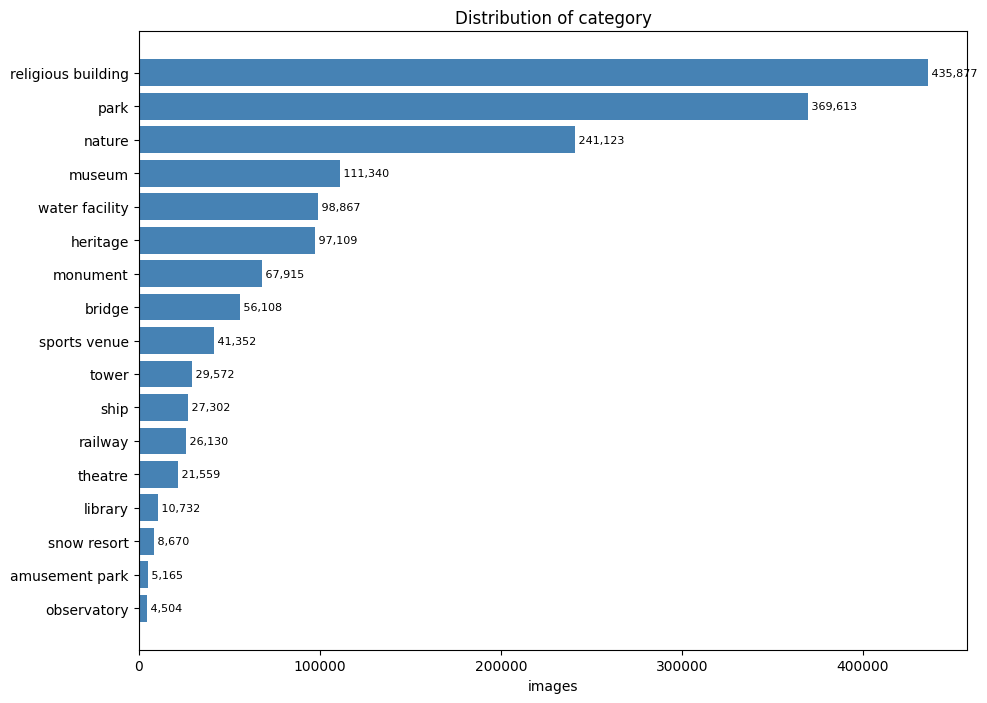

In [84]:
# 1. Distribution of the category column
cat_dist = (
    eda.group_by("category")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .with_columns((pl.col("n") / pl.col("n").sum()).alias("pct"))
)

# with pl.Config(tbl_rows=-1):
#     print(cat_dist)

fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * len(cat_dist))))
ax.barh(cat_dist["category"], cat_dist["n"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("images")
ax.set_title("Distribution of category")
for y, v in enumerate(cat_dist["n"]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

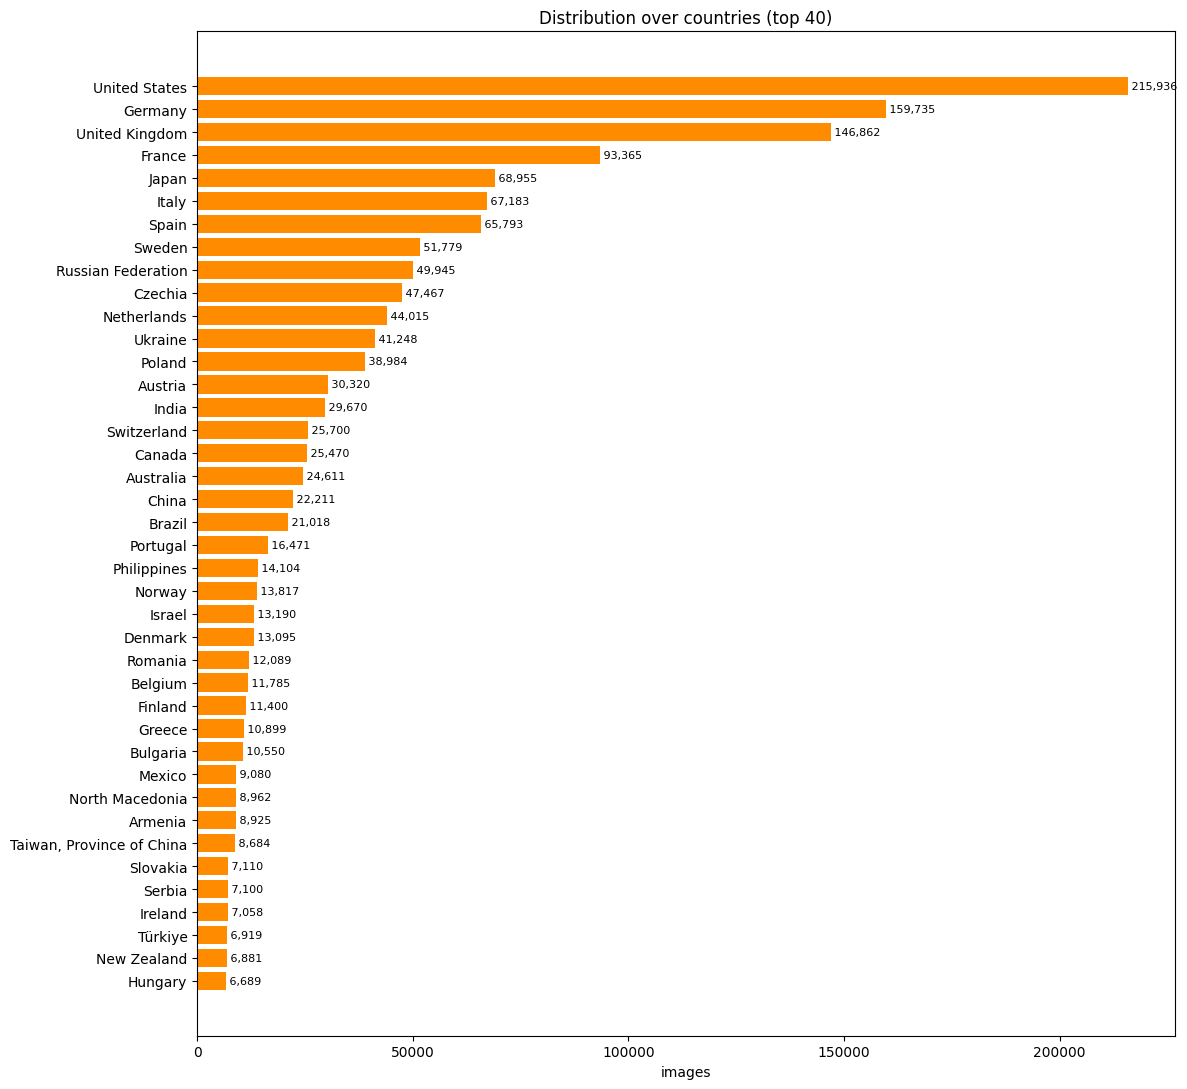

In [85]:
# 2. Distribution of data over countries
country_dist = (
    eda_geo.group_by("country")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .with_columns(
        (pl.col("n") / pl.col("n").sum()).alias("pct"),
        (pl.col("n").cum_sum() / pl.col("n").sum()).alias("cum_pct"),
    )
)

# with pl.Config(tbl_rows=-1):
#     print(country_dist)

topk = country_dist.head(40)
fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(topk["country"], topk["n"], color="darkorange")
ax.invert_yaxis()
ax.set_xlabel("images")
ax.set_title("Distribution over countries (top 40)")
for y, v in enumerate(topk["n"]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Category distribution with a per-country breakdown  ->  CSV
TOP_COUNTRIES = 12
top_countries = country_dist.head(TOP_COUNTRIES)["country"].to_list()

# wide pivot: top countries as columns + "Other"
brk = (
    eda_geo.with_columns(
        pl.when(pl.col("country").is_in(top_countries))
        .then(pl.col("country"))
        .otherwise(pl.lit("Other"))
        .alias("country_grp")
    )
    .group_by(["category", "country_grp"])
    .agg(pl.len().alias("n"))
)
col_order = top_countries + ["Other"]
pivot = (
    brk.pivot(values="n", index="category", on="country_grp")
    .fill_null(0)
    .sort("category")
)
pivot = pivot.select(["category"] + [c for c in col_order if c in pivot.columns])
pivot.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/eda_category_by_country_top{}.csv".format(
        TOP_COUNTRIES
    )
)

# full long form: every category x country pair, plus share within category
cat_country_long = (
    eda_geo.group_by(["category", "country"])
    .agg(pl.len().alias("n"))
    .with_columns(
        (pl.col("n") / pl.col("n").sum().over("category")).alias("share_in_category")
    )
    .sort(["category", "n"], descending=[False, True])
)
cat_country_long.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/eda_category_by_country_full.csv"
)
print(
    "wrote eda_category_by_country_top{}.csv + eda_category_by_country_full.csv".format(
        TOP_COUNTRIES
    )
)

# # charts stay in the notebook
# cats = pivot["category"].to_list()
# stack_cols = [c for c in pivot.columns if c != "category"]
# mat = np.array([pivot[c].to_list() for c in stack_cols], dtype=float)  # cols x cats
# share = mat / mat.sum(axis=0, keepdims=True)
# cmap = plt.cm.tab20(np.linspace(0, 1, len(stack_cols)))

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# for data, ax, title in (
#     (mat, axes[0], "Category composition by country (counts)"),
#     (share, axes[1], "Category composition by country (share within category)"),
# ):
#     bottoms = np.zeros(len(cats))
#     for i, col in enumerate(stack_cols):
#         ax.bar(cats, data[i], bottom=bottoms, label=col, color=cmap[i])
#         bottoms += data[i]
#     ax.set_title(title)
#     ax.tick_params(axis="x", rotation=90)
# axes[0].set_ylabel("images")
# axes[1].set_ylabel("share")
# axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# plt.tight_layout()
# plt.show()

wrote eda_category_by_country_top12.csv + eda_category_by_country_full.csv


In [ ]:
# 4a. Full country x category count matrix (every cell)  ->  CSV
matrix = (
    eda_geo.group_by(["country", "category"])
    .agg(pl.len().alias("n"))
    .pivot(values="n", index="country", on="category")
    .fill_null(0)
)
cat_cols = [c for c in matrix.columns if c != "country"]
ordered_cats = sorted(cat_cols, key=lambda c: matrix[c].sum(), reverse=True)
matrix = (
    matrix.with_columns(pl.sum_horizontal(cat_cols).alias("total"))
    .sort("total", descending=True)
    .select(["country"] + ordered_cats + ["total"])
)
matrix.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/eda_country_x_category_matrix.csv"
)
print(
    "wrote eda_country_x_category_matrix.csv "
    f"({matrix.height} countries x {len(ordered_cats)} categories)"
)

wrote eda_country_x_category_matrix.csv (240 countries x 17 categories)


In [ ]:
group_per_url = df_tag_clean.group_by("wikimedia_url").agg(
    pl.col("country").n_unique().alias("n_country"),
    pl.col("category").n_unique().alias("n_category"),
    pl.len().alias("n_images"),
)

In [100]:
group_per_url.select(
    (pl.col("n_country") > 1).sum().alias("urls_multi_country"),
    (pl.col("n_category") > 1).sum().alias("urls_multi_category"),
)

urls_multi_country,urls_multi_category
u32,u32
0,74


#### Wikimedia URL Disjoint Split

In [125]:
url_cell = (
    df_tag_clean.group_by(["wikimedia_url", "country", "category"])
    .agg(pl.len().alias("n_images"))
    .sort(["wikimedia_url", "n_images"], descending=[False, True])
    .group_by("wikimedia_url", maintain_order=True)
    .first()
    .select(["wikimedia_url", "country", "category", "n_images"])
)

url_cell.head()

wikimedia_url,country,category,n_images
str,str,str,u32
"""https://commons.wikimedia.org/…","""Moldova, Republic of""","""theatre""",2
"""https://commons.wikimedia.org/…","""Russian Federation""","""museum""",1
"""https://commons.wikimedia.org/…","""Hungary""","""museum""",13
"""https://commons.wikimedia.org/…","""Sweden""","""museum""",9
"""https://commons.wikimedia.org/…","""Iceland""","""water facility""",19


In [ ]:
cells = (
    url_cell.group_by(["country", "category"])
    .agg(pl.len().alias("W"), pl.col("n_images").sum().alias("n_images"))
    .sort("W")
)
cells

country,category,W,n_images
str,str,u32,u32
"""Senegal""","""heritage""",1,3
"""Uganda""","""museum""",1,25
"""Malawi""","""heritage""",1,6
"""Sao Tome and Principe""","""museum""",1,60
"""Switzerland""","""ship""",1,41
…,…,…,…
"""Italy""","""religious building""",2615,19818
"""United Kingdom""","""religious building""",2823,32959
"""United States""","""park""",3446,96368


In [118]:
cells.select(
    pl.col("W").min().alias("min"),
    pl.col("W").quantile(0.25).alias("p25"),
    pl.col("W").median().alias("p50"),
    pl.col("W").quantile(0.75).alias("p75"),
    pl.col("W").quantile(0.90).alias("p90"),
    pl.col("W").max().alias("max"),
    pl.col("W").mean().alias("mean"),
)

min,p25,p50,p75,p90,max,mean
u32,f64,f64,f64,f64,u32,f64
1,2.0,5.0,17.0,84.0,4879,51.59816


In [ ]:
tiered = cells.with_columns(
    pl.when(pl.col("W") == 1)
    .then(pl.lit("W=1"))
    .when(pl.col("W") == 2)
    .then(pl.lit("W=2"))
    .when(pl.col("W") < 7)
    .then(pl.lit("W 3-6"))
    .when(pl.col("W") < 20)
    .then(pl.lit("W 7-19"))
    .otherwise(pl.lit("W>=20"))
    .alias("tier")
)

tiered.group_by("tier").agg(
    pl.len().alias("cells"),
    pl.col("W").sum().alias("urls"),
    pl.col("n_images").sum().alias("images"),
).sort("cells", descending=True)

tier,cells,urls,images
str,u32,u32,u32
"""W=1""",477,477,5494
"""W>=20""",456,93662,1504554
"""W 7-19""",399,4700,105528
"""W 3-6""",394,1627,29375
"""W=2""",230,460,7645


In [ ]:
SMALL = 5

cells = cells.with_columns((pl.col("W") >= SMALL).alias("splittable"))

total_img = cells["n_images"].sum()
cells.group_by("splittable").agg(
    pl.len().alias("cells"),
    pl.col("W").sum().alias("urls"),
    pl.col("n_images").sum().alias("images"),
    (pl.col("n_images").sum() / total_img).alias("img_share"),
)

splittable,cells,urls,images,img_share
bool,u32,u32,u32,f64
false,962,1815,28029,0.016961
true,994,99111,1624567,0.983039


In [ ]:
import numpy as np

SEED = 42
F_VAL = 0.15
F_TEST = 0.15

url_df = url_cell.join(
    cells.select(["country", "category", "W"]),
    on=["country", "category"],
    how="left",
)

rng = np.random.default_rng(SEED)
url_df = url_df.with_columns(u=pl.Series("u", rng.random(url_df.height)))

url_df = (
    url_df.with_columns(
        rk=pl.col("u").rank("ordinal").over(["country", "category"])
        - 1  # 0..W-1 within cell
    )
    .with_columns(
        n_test=pl.when(pl.col("W") >= SMALL)
        .then(pl.max_horizontal(pl.lit(1), (F_TEST * pl.col("W")).round()))
        .otherwise(0)
        .cast(pl.Int64),
        n_val=pl.when(pl.col("W") >= SMALL)
        .then(pl.max_horizontal(pl.lit(1), (F_VAL * pl.col("W")).round()))
        .otherwise(0)
        .cast(pl.Int64),
    )
    .with_columns(
        split=pl.when(pl.col("W") < SMALL)
        .then(pl.lit("train"))
        .when(pl.col("rk") < pl.col("n_test"))
        .then(pl.lit("test"))
        .when(pl.col("rk") < pl.col("n_test") + pl.col("n_val"))
        .then(pl.lit("val"))
        .otherwise(pl.lit("train"))
    )
)

url_df["split"].value_counts()

split,count
str,u32
"""test""",14891
"""val""",14891
"""train""",71144


In [ ]:
img_split = df_tag_clean.join(
    url_df.select(["wikimedia_url", "split"]), on="wikimedia_url", how="left"
)

print("images with no split:", img_split["split"].null_count())  # expect 0

leak = (
    img_split.group_by("wikimedia_url")
    .agg(pl.col("split").n_unique().alias("n_splits"))
    .filter(pl.col("n_splits") > 1)
)
print("URLs spanning >1 split:", leak.height)

images with no split: 0
URLs spanning >1 split: 0


In [136]:
# image-level split ratio (target 70/15/15)
img_split.group_by("split").agg(
    pl.len().alias("images"),
    (pl.len() / img_split.height).alias("frac"),
)

split,images,frac
str,u32,f64
"""test""",245891,0.14876
"""train""",1166373,0.705636
"""val""",240674,0.145604


In [137]:
# every category present in every split?
img_split.group_by("split").agg(pl.col("category").n_unique().alias("n_categories"))

split,n_categories
str,u32
"""val""",17
"""test""",17
"""train""",17


In [ ]:
# per country x category: how many of the 3 folds are covered
cover = (
    img_split.group_by(["country", "category"])
    .agg(pl.col("split").n_unique().alias("folds"))
    .group_by("folds")
    .agg(pl.len().alias("cells"))
    .sort("folds")
)
cover

folds,cells
u32,u32
1,962
2,1
3,994


In [ ]:
img_split.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/all_preprocessed_data.csv"
)

In [ ]:
img_split.filter(pl.col("split") == "train").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/train.csv"
)
img_split.filter(pl.col("split") == "val").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/val.csv"
)
img_split.filter(pl.col("split") == "test").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/test.csv"
)

### Query & Caption Generation

#### Caption Generation

We need the caption to finetune CLIP later. Run this script to do it:
```bash
python -m src.data.zeroshot_caption_llm \
    --data-path /mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/all_preprocessed_data.csv \
    --output-path /mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/all_generated_captions.csv \
    --infer-concurrency 64 
    --loader-workers 32
```

In [ ]:
caption = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/all_generated_captions.csv"
)
caption.head()

id,caption,caption_words,caption_truncated
str,str,i64,str
"""747804ef2ce10499""","""A weathered stone ruin with a …",15,"""no"""
"""f777af413a5cdf23""","""A weathered stone theatre with…",12,"""no"""
"""b87423b2533efb94""","""A historic stone building with…",15,"""no"""
"""816e0e62c2e5e858""","""A weathered stone wall with a …",15,"""no"""
"""55de725869e41f48""","""A stone church with a tall spi…",15,"""no"""


In [151]:
train = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/train.csv")
val = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/val.csv")
index = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/test.csv")

In [160]:
train.join(caption.select(["id", "caption"]), on="id", how="left").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/train.csv"
)
val.join(caption.select(["id", "caption"]), on="id", how="left").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/val.csv"
)
index.join(caption.select(["id", "caption"]), on="id", how="left").write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/test.csv"
)

#### Query Generation

In [184]:
# ISO 3166 "inverted" names read unnaturally in a query ("Korea, Republic of");
# remap the comma forms to their natural phrasing.
COUNTRY_DISPLAY = {
    "Bolivia, Plurinational State of": "Plurinational State of Bolivia",
    "Congo, The Democratic Republic of the": "Democratic Republic of the Congo",
    "Iran, Islamic Republic of": "Islamic Republic of Iran",
    "Korea, Democratic People's Republic of": "Democratic People's Republic of Korea",
    "Korea, Republic of": "Republic of Korea",
    "Micronesia, Federated States of": "Federated States of Micronesia",
    "Moldova, Republic of": "Republic of Moldova",
    "Palestine, State of": "State of Palestine",
    "Saint Helena, Ascension and Tristan da Cunha": "Saint Helena",
    "Taiwan, Province of China": "Taiwan",
    "Tanzania, United Republic of": "United Republic of Tanzania",
    "Venezuela, Bolivarian Republic of": "Bolivarian Republic of Venezuela",
    "Virgin Islands, British": "British Virgin Islands",
    "Virgin Islands, U.S.": "U.S. Virgin Islands",
    # kept as-is: genuine multi-island name, not an inversion artifact
    "Bonaire, Sint Eustatius and Saba": "Bonaire, Sint Eustatius and Saba",
}

countries = [
    COUNTRY_DISPLAY.get(c, c) for c in img_split["country"].unique().to_list()
]
categories = img_split["category"].unique().to_list()

len(countries), len(categories)

(240, 17)

In [181]:
queries = []
for ctr in countries:
    for cat in categories:
        queries.append(f"a {cat} located in {ctr}")

In [ ]:
import json

TEST_CSV = "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/test.csv"
OUT_JSON = "/mnt/yokoyamalab-nas/gldv2-full/csv/queries/test_templated_queries.json"

# ground truth = test.csv `id` values per (category, country) pair
test_df = pl.read_csv(TEST_CSV, infer_schema_length=20000)
gt_lookup = {
    (r["category"], r["country"]): r["relevant_ids"]
    for r in test_df.group_by(["category", "country"])
    .agg(pl.col("id").sort().alias("relevant_ids"))
    .iter_rows(named=True)
}

# country -> region (1:1 in the full dataset)
country2region = dict(img_split.select(["country", "region"]).unique().iter_rows())

raw_countries = sorted(img_split["country"].unique().to_list())
raw_categories = sorted(img_split["category"].unique().to_list())

data = []
for ctr in raw_countries:
    disp = COUNTRY_DISPLAY.get(ctr, ctr)
    for cat in raw_categories:
        data.append({
            "text": f"a {cat} located in {disp}",
            "category": cat,
            "country": disp,
            "region": country2region.get(ctr, ""),
            "relevant_ids": list(gt_lookup.get((cat, ctr), [])),
        })

assert len(data) == len(raw_countries) * len(raw_categories) == 4080, len(data)
with open(OUT_JSON, "w") as f:
    json.dump({"data": data}, f)

n_gt = sum(1 for d in data if d["relevant_ids"])
print(f"wrote {len(data)} queries ({n_gt} with ground truth, {len(data) - n_gt} empty) -> {OUT_JSON}")

wrote 4080 queries (994 with ground truth, 3086 empty) -> /mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/test_templated_queries.json
